# Lab 07: Hypothesis Testing (Kiểm định giả thuyết)
**Student ID:** 523H0164  
**Date:** November 20, 2025  

---

## Learning Objectives:
- Hiểu và thực hiện các loại kiểm định giả thuyết (Hypothesis Testing)
- Kiểm định một mẫu (One-sample tests): t-test, z-test
- Kiểm định hai mẫu độc lập (Two-sample independent tests)
- Kiểm định ghép cặp (Paired t-test)
- Kiểm định Chi-square cho tính độc lập
- ANOVA (Analysis of Variance) để so sánh nhiều nhóm
- Diễn giải p-value và đưa ra kết luận thống kê

---

## Dataset:
- **File:** `laptops_asus_data_cellphones_full_v2.csv`
- **Features:** Price, RAM, GPU, Storage, Screen, etc.
- **Target:** Statistical inference about laptop characteristics

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Reuse preprocessing from previous labs
def preprocess_laptop_data(df):
    df['Price_VND'] = (df['Price'].astype(str)
                       .str.replace('đ','', regex=False)
                       .str.replace('.','', regex=False)
                       .str.strip())
    df['Price_VND'] = pd.to_numeric(df['Price_VND'], errors='coerce')
    df['RAM_GB'] = (df['RAM'].astype(str)
                    .str.replace('GB','', regex=False)
                    .str.strip())
    df['RAM_GB'] = pd.to_numeric(df['RAM_GB'], errors='coerce')
    def classify_gpu_type(gpu_str):
        if pd.isna(gpu_str): return 'Unknown'
        s = str(gpu_str).lower()
        if any(x in s for x in ['rtx','gtx','radeon','nvidia','amd']):
            return 'Dedicated'
        return 'Integrated'
    df['GPU_Type'] = df['GPU'].apply(classify_gpu_type)
    def price_segment(price):
        if pd.isna(price): return 'Unknown'
        if price < 15000000: return 'Budget'
        if price < 25000000: return 'Mid-range'
        if price < 40000000: return 'High-end'
        return 'Premium'
    df['Price_Segment'] = df['Price_VND'].apply(price_segment)
    return df.dropna(subset=['Price_VND','RAM_GB'])

df = pd.read_csv('laptops_asus_data_cellphones_full_v2.csv')
df = preprocess_laptop_data(df)
print(f"Data loaded: {df.shape}")

Data loaded: (574, 16)


---
## Setup: Import Libraries & Load Data

Chúng ta sẽ sử dụng các thư viện quen thuộc và tái sử dụng hàm tiền xử lý từ các lab trước.

---
# Part 1: One-Sample Tests (Kiểm định một mẫu)

## Theory:
Kiểm định một mẫu được sử dụng khi chúng ta muốn kiểm tra xem một tham số của tổng thể (như trung bình hoặc tỷ lệ) có bằng một giá trị cụ thể hay không.

### 1.1 One-Sample t-test (Kiểm định trung bình)
- **H₀ (Null hypothesis):** μ = μ₀
- **H₁ (Alternative hypothesis):** μ ≠ μ₀ (two-tailed)
- **Test statistic:** $t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}}$
- **Decision rule:** Reject H₀ if p-value < α

### 1.2 One-Sample z-test (Kiểm định tỷ lệ)
- **H₀:** p = p₀
- **H₁:** p ≠ p₀
- **Test statistic:** $z = \frac{\hat{p} - p_0}{\sqrt{p_0(1-p_0)/n}}$

---

## Exercises:

**Example:** Kiểm tra xem tỷ lệ laptop có GPU rời có khác 50% hay không (H₀: p = 0.5)

In [10]:
# Example: One-sample proportion test (GPU Dedicated vs 50%)
n = len(df)
p_hat = (df['GPU_Type'] == 'Dedicated').mean()
p0 = 0.5  # null hypothesis
se_p = np.sqrt(p0 * (1 - p0) / n)
z_stat = (p_hat - p0) / se_p
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"Example: One-sample proportion test (H₀: p=0.5)")
print(f"n={n}, p̂={p_hat:.4f}, z={z_stat:.4f}, p-value={p_value:.4f}")
print(f"Conclusion: {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'} at α=0.05")
print(f"=> Tỷ lệ laptop có GPU rời {'khác' if p_value < 0.05 else 'không khác'} với 50%\n")

# Example: One-sample t-test for mean price (H₀: μ = 25,000,000)
mu0 = 25000000
t_stat, p_val_mean = stats.ttest_1samp(df['Price_VND'], popmean=mu0)
print(f"Example: One-sample t-test (H₀: μ={mu0:,})")
print(f"t={t_stat:.4f}, p-value={p_val_mean:.4f}")
print(f"Conclusion: {'Reject H₀' if p_val_mean < 0.05 else 'Fail to reject H₀'} at α=0.05")

Example: One-sample proportion test (H₀: p=0.5)
n=574, p̂=0.5819, z=3.9235, p-value=0.0001
Conclusion: Reject H₀ at α=0.05
=> Tỷ lệ laptop có GPU rời khác với 50%

Example: One-sample t-test (H₀: μ=25,000,000)
t=3.6151, p-value=0.0003
Conclusion: Reject H₀ at α=0.05


In [11]:
# Exercise 1.1: Test if mean RAM is different from 8GB (α=0.05)
# H₀: μ_RAM = 8
# H₁: μ_RAM ≠ 8
print("="*60)
print("EXERCISE 1.1: Test Mean RAM vs 8GB")
print("="*60)
t_ram, p_ram = stats.ttest_1samp(df['RAM_GB'], popmean=8)
print(f"Mean RAM: {df['RAM_GB'].mean():.2f} GB")
print(f"t-statistic: {t_ram:.4f}")
print(f"p-value: {p_ram:.4e}")
print(f"Decision: {'Reject H₀' if p_ram < 0.05 else 'Fail to reject H₀'} at α=0.05")
if p_ram < 0.05:
    print("=> Mean RAM is significantly different from 8GB.")
else:
    print("=> Mean RAM is not significantly different from 8GB.")

# Exercise 1.2: Test if proportion of 'Budget' laptops is less than 20%
# H₀: p ≥ 0.2
# H₁: p < 0.2 (One-sided test, left-tailed)
print("\n" + "="*60)
print("EXERCISE 1.2: Test Proportion of Budget Laptops < 20%")
print("="*60)
p_bud = (df['Price_Segment'] == 'Budget').mean()
p0_bud = 0.2
z_bud = (p_bud - p0_bud) / np.sqrt(p0_bud*(1-p0_bud)/n)
p_val_bud = stats.norm.cdf(z_bud)  # Left tail for H₁: p < p₀
print(f"Sample proportion (Budget): {p_bud:.4f} ({p_bud*100:.2f}%)")
print(f"z-statistic: {z_bud:.4f}")
print(f"p-value (one-tailed): {p_val_bud:.4f}")
print(f"Decision: {'Reject H₀' if p_val_bud < 0.05 else 'Fail to reject H₀'} at α=0.05")
if p_val_bud < 0.05:
    print("=> Proportion of Budget laptops is significantly less than 20%.")
else:
    print("=> Not enough evidence to conclude proportion is less than 20%.")

EXERCISE 1.1: Test Mean RAM vs 8GB
Mean RAM: 14.89 GB
t-statistic: 15.4176
p-value: 4.0696e-45
Decision: Reject H₀ at α=0.05
=> Mean RAM is significantly different from 8GB.

EXERCISE 1.2: Test Proportion of Budget Laptops < 20%
Sample proportion (Budget): 0.1899 (18.99%)
z-statistic: -0.6052
p-value (one-tailed): 0.2725
Decision: Fail to reject H₀ at α=0.05
=> Not enough evidence to conclude proportion is less than 20%.


---
# Part 2: Two-Sample Independent Tests (Kiểm định hai mẫu độc lập)

## Theory:
Kiểm định hai mẫu độc lập được sử dụng để so sánh hai nhóm khác nhau.

### 2.1 Two-Sample t-test (Welch's t-test)
- **H₀:** μ₁ = μ₂
- **H₁:** μ₁ ≠ μ₂
- **Assumption:** Không yêu cầu phương sai bằng nhau (unequal variances)
- **Use case:** So sánh trung bình giá giữa laptop có GPU rời và GPU tích hợp

### 2.2 Two-Sample Proportion Test (z-test)
- **H₀:** p₁ = p₂
- **H₁:** p₁ ≠ p₂
- **Pooled proportion:** $\hat{p} = \frac{x_1 + x_2}{n_1 + n_2}$
- **Test statistic:** $z = \frac{\hat{p}_1 - \hat{p}_2}{SE}$

---

## Exercises:

**Example:** So sánh giá trung bình giữa laptop có GPU rời và GPU tích hợp

In [12]:
# Example: Two-sample t-test (Dedicated vs Integrated GPU)
g = df[df['GPU_Type'] == 'Dedicated']['Price_VND']
ng = df[df['GPU_Type'] == 'Integrated']['Price_VND']
t2, p2 = stats.ttest_ind(g, ng, equal_var=False)

print("Example: Two-sample t-test (Dedicated GPU vs Integrated GPU)")
print(f"Mean Price (Dedicated):  {g.mean():,.0f} VND (n={len(g)})")
print(f"Mean Price (Integrated): {ng.mean():,.0f} VND (n={len(ng)})")
print(f"t-statistic: {t2:.4f}")
print(f"p-value: {p2:.4e}")
print(f"Conclusion: {'Reject H₀' if p2 < 0.05 else 'Fail to reject H₀'} at α=0.05")
print(f"=> Giá trung bình {'khác nhau' if p2 < 0.05 else 'không khác nhau'} giữa hai loại GPU\n")

# Two-sample proportion test function
def two_prop_ztest(count1, n1, count2, n2):
    """Two-proportion z-test"""
    p1 = count1 / n1
    p2 = count2 / n2
    p_pool = (count1 + count2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z = (p1 - p2) / se
    pval = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, pval, p1, p2

# Example: Compare RAM >=16GB between Premium and Budget
prem = df[df['Price_Segment'] == 'Premium']
bud = df[df['Price_Segment'] == 'Budget']
count_p = (prem['RAM_GB'] >= 16).sum()
count_b = (bud['RAM_GB'] >= 16).sum()
zprop, pprop, prop_p, prop_b = two_prop_ztest(count_p, len(prem), count_b, len(bud))

print("Example: Two-proportion test (RAM ≥16GB: Premium vs Budget)")
print(f"Proportion Premium (RAM≥16GB): {prop_p:.4f} ({count_p}/{len(prem)})")
print(f"Proportion Budget (RAM≥16GB):  {prop_b:.4f} ({count_b}/{len(bud)})")
print(f"z-statistic: {zprop:.4f}")
print(f"p-value: {pprop:.4e}")
print(f"Conclusion: {'Reject H₀' if pprop < 0.05 else 'Fail to reject H₀'} at α=0.05")

Example: Two-sample t-test (Dedicated GPU vs Integrated GPU)
Mean Price (Dedicated):  33,898,563 VND (n=334)
Mean Price (Integrated): 19,405,941 VND (n=239)
t-statistic: 11.0538
p-value: 1.6143e-25
Conclusion: Reject H₀ at α=0.05
=> Giá trung bình khác nhau giữa hai loại GPU

Example: Two-proportion test (RAM ≥16GB: Premium vs Budget)
Proportion Premium (RAM≥16GB): 1.0000 (94/94)
Proportion Budget (RAM≥16GB):  0.1468 (16/109)
z-statistic: 12.1659
p-value: 0.0000e+00
Conclusion: Reject H₀ at α=0.05



EXERCISE 2.1: Compare Mean RAM (High-end vs Premium)
Mean RAM (High-end): 17.18 GB (n=142)
Mean RAM (Premium):  29.11 GB (n=94)
t-statistic: -6.8134
p-value: 0.0000
Decision: Reject H₀ at α=0.05
=> Mean RAM differs significantly between High-end and Premium.

[Visualization] Price Distribution by GPU Type:


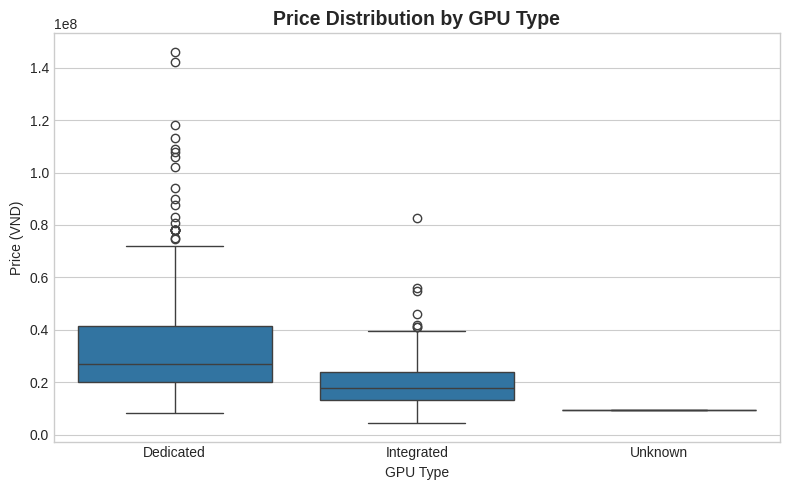

In [13]:
# Exercise 2.1: Compare Mean RAM between High-end vs Premium
print("\n" + "="*60)
print("EXERCISE 2.1: Compare Mean RAM (High-end vs Premium)")
print("="*60)
high_ram = df[df['Price_Segment'] == 'High-end']['RAM_GB']
prem_ram = df[df['Price_Segment'] == 'Premium']['RAM_GB']
t_ram2, p_ram2 = stats.ttest_ind(high_ram, prem_ram, equal_var=False)

print(f"Mean RAM (High-end): {high_ram.mean():.2f} GB (n={len(high_ram)})")
print(f"Mean RAM (Premium):  {prem_ram.mean():.2f} GB (n={len(prem_ram)})")
print(f"t-statistic: {t_ram2:.4f}")
print(f"p-value: {p_ram2:.4f}")
print(f"Decision: {'Reject H₀' if p_ram2 < 0.05 else 'Fail to reject H₀'} at α=0.05")
if p_ram2 < 0.05:
    print("=> Mean RAM differs significantly between High-end and Premium.")
else:
    print("=> No significant difference in mean RAM.")

# Visualization: Boxplot for Price by GPU Type
print("\n[Visualization] Price Distribution by GPU Type:")
plt.figure(figsize=(8, 5))
sns.boxplot(x='GPU_Type', y='Price_VND', data=df)
plt.title('Price Distribution by GPU Type', fontsize=14, fontweight='bold')
plt.xlabel('GPU Type')
plt.ylabel('Price (VND)')
plt.tight_layout()
plt.show()

---
# Part 3: Paired t-test (Kiểm định ghép cặp)

## Theory:
Kiểm định ghép cặp được sử dụng khi hai mẫu có liên hệ với nhau (cùng một đối tượng trước và sau, hoặc các cặp matched).

### Paired t-test
- **H₀:** μ_d = 0 (mean difference = 0)
- **H₁:** μ_d ≠ 0
- **Assumption:** Các cặp phải phụ thuộc lẫn nhau
- **Use case:** So sánh giá trước và sau khuyến mãi, so sánh performance trước và sau training

**Note:** Trong dataset này, chúng ta sẽ tạo pseudo-pairs từ các laptop có cùng tên model nhưng khác cấu hình để minh họa phương pháp.

---

## Exercise:

In [14]:
# Paired t-test: construct pseudo-pairs by model name
# Find laptops with same model name but different configurations
pairs = df.groupby('Name').filter(lambda g: len(g) >= 2)
pairs_count = pairs['Name'].nunique()

print("="*60)
print("EXERCISE 3: Paired t-test (Pseudo-pairs)")
print("="*60)
print(f"Number of laptop models with ≥2 configurations: {pairs_count}")

# Take models with multiple variants and pair their prices
paired_names = pairs['Name'].value_counts()[lambda x: x>=2].index.tolist()[:50]
before = []
after = []

for name in paired_names:
    rows = df[df['Name'] == name].sort_values('Price_VND')
    if len(rows) >= 2:
        before.append(rows['Price_VND'].iloc[0])  # Lower price config
        after.append(rows['Price_VND'].iloc[1])   # Higher price config

if len(before) >= 2:
    t_p, p_p = stats.ttest_rel(before, after)
    print(f"\nNumber of paired samples: {len(before)}")
    print(f"Mean difference (after - before): {np.mean(np.array(after) - np.array(before)):,.0f} VND")
    print(f"t-statistic: {t_p:.4f}")
    print(f"p-value: {p_p:.4f}")
    print(f"Decision: {'Reject H₀' if p_p < 0.05 else 'Fail to reject H₀'} at α=0.05")
    if p_p < 0.05:
        print("=> Có sự khác biệt có ý nghĩa giữa các cấu hình của cùng model.")
    else:
        print("=> Không đủ bằng chứng để kết luận có sự khác biệt.")
else:
    print('Not enough paired samples for demonstration.')

print("\n[Note] Paired t-test yêu cầu dữ liệu có sự ghép cặp tự nhiên.")
print("Trong thực tế, dùng cho: before/after studies, matched case-control, etc.")

EXERCISE 3: Paired t-test (Pseudo-pairs)
Number of laptop models with ≥2 configurations: 8

Number of paired samples: 8
Mean difference (after - before): 2,510,000 VND
t-statistic: -2.3548
p-value: 0.0507
Decision: Fail to reject H₀ at α=0.05
=> Không đủ bằng chứng để kết luận có sự khác biệt.

[Note] Paired t-test yêu cầu dữ liệu có sự ghép cặp tự nhiên.
Trong thực tế, dùng cho: before/after studies, matched case-control, etc.


---
# Part 4: Chi-Square Test for Independence (Kiểm định Chi-square)

## Theory:
Kiểm định Chi-square được sử dụng để kiểm tra tính độc lập giữa hai biến phân loại (categorical variables).

### Chi-Square Test
- **H₀:** Hai biến độc lập với nhau (no association)
- **H₁:** Hai biến có mối liên hệ (association exists)
- **Test statistic:** $\chi^2 = \sum \frac{(O - E)^2}{E}$
  - O = Observed frequency
  - E = Expected frequency
- **Use case:** Kiểm tra mối quan hệ giữa GPU Type và Price Segment

---

## Exercises:

Example: Chi-square test for independence
Variables: GPU_Type vs Price_Segment
χ² = 124.67
p-value = 1.7001e-24
Degrees of freedom = 6
Decision: Reject H₀ at α=0.05
=> GPU Type và Price Segment có mối liên hệ (dependent).

Contingency Table (Observed frequencies):
Price_Segment  Budget  High-end  Mid-range  Premium
GPU_Type                                           
Dedicated          21        99        127       87
Integrated         87        43        102        7
Unknown             1         0          0        0

EXERCISE 4.1: Chi-square test (RAM_GB vs Price_Segment)
χ² = 521.77
p-value = 2.7499e-99
Degrees of freedom = 18
Decision: Reject H₀ at α=0.05
=> RAM và Price Segment có mối liên hệ.

Contingency Table (RAM vs Price Segment):
Price_Segment  Budget  High-end  Mid-range  Premium
RAM_GB                                             
4.00               46         0          2        0
8.00               47        27        138        0
16.00              16        89         

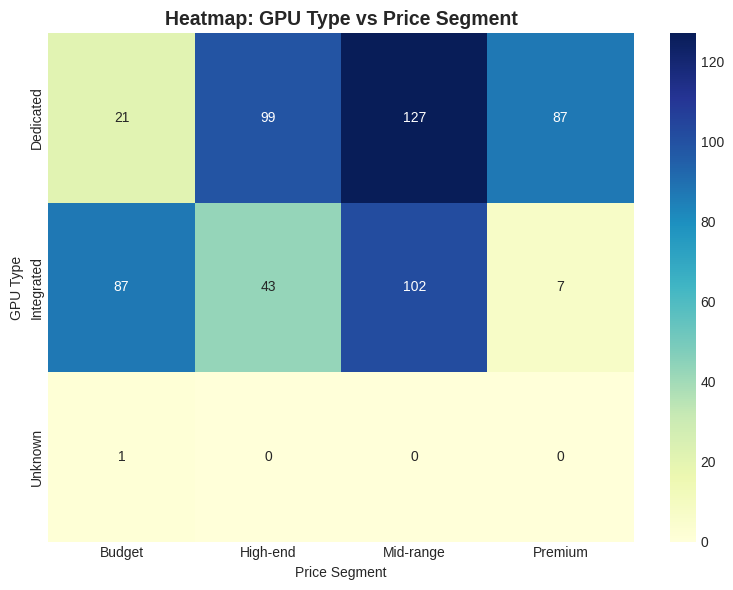

In [15]:
# Example: Chi-square test (GPU_Type vs Price_Segment)
contingency = pd.crosstab(df['GPU_Type'], df['Price_Segment'])
chi2, p_chi, dof, ex = stats.chi2_contingency(contingency)

print("Example: Chi-square test for independence")
print("Variables: GPU_Type vs Price_Segment")
print(f"χ² = {chi2:.2f}")
print(f"p-value = {p_chi:.4e}")
print(f"Degrees of freedom = {dof}")
print(f"Decision: {'Reject H₀' if p_chi < 0.05 else 'Fail to reject H₀'} at α=0.05")
if p_chi < 0.05:
    print("=> GPU Type và Price Segment có mối liên hệ (dependent).")
else:
    print("=> GPU Type và Price Segment độc lập với nhau.")

print('\nContingency Table (Observed frequencies):')
print(contingency)

# Exercise 4.1: Test independence between RAM_GB and Price_Segment
print("\n" + "="*60)
print("EXERCISE 4.1: Chi-square test (RAM_GB vs Price_Segment)")
print("="*60)
contingency_ram = pd.crosstab(df['RAM_GB'], df['Price_Segment'])
chi2_ram, p_ram_chi, dof_ram, ex_ram = stats.chi2_contingency(contingency_ram)

print(f"χ² = {chi2_ram:.2f}")
print(f"p-value = {p_ram_chi:.4e}")
print(f"Degrees of freedom = {dof_ram}")
print(f"Decision: {'Reject H₀' if p_ram_chi < 0.05 else 'Fail to reject H₀'} at α=0.05")
if p_ram_chi < 0.05:
    print("=> RAM và Price Segment có mối liên hệ.")
else:
    print("=> RAM và Price Segment độc lập với nhau.")

print("\nContingency Table (RAM vs Price Segment):")
print(contingency_ram)

# Visualization: Heatmap of Contingency Table
print("\n[Visualization] Heatmap: GPU Type vs Price Segment")
plt.figure(figsize=(8, 6))
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap: GPU Type vs Price Segment', fontsize=14, fontweight='bold')
plt.xlabel('Price Segment')
plt.ylabel('GPU Type')
plt.tight_layout()
plt.show()

---
# Part 5: ANOVA - Analysis of Variance (Phân tích phương sai)

## Theory:
ANOVA được sử dụng để so sánh trung bình của **ba hoặc nhiều nhóm** cùng lúc.

### One-Way ANOVA
- **H₀:** μ₁ = μ₂ = μ₃ = ... = μₖ (all group means are equal)
- **H₁:** Ít nhất một nhóm có trung bình khác biệt
- **Test statistic:** F = MS_between / MS_within
- **Use case:** So sánh RAM trung bình giữa 4 Price Segments

**Note:** Nếu ANOVA cho thấy có sự khác biệt (reject H₀), cần thực hiện **post-hoc tests** (như Tukey's HSD) để xác định nhóm nào khác biệt với nhóm nào.

---

## Exercise:

EXERCISE 5: One-way ANOVA (RAM across Price Segments)
Budget      : n=109, Mean RAM=7.49 GB, Std=4.00
Mid-range   : n=229, Mean RAM=11.14 GB, Std=4.18
High-end    : n=142, Mean RAM=17.18 GB, Std=7.25
Premium     : n= 94, Mean RAM=29.11 GB, Std=15.91

F-statistic: 149.9612
p-value: 1.2334e-71
Decision: Reject H₀ at α=0.05
=> Ít nhất một segment có mean RAM khác biệt có ý nghĩa.
   (Cần thực hiện post-hoc test như Tukey HSD để xác định nhóm nào khác nhau)

[Visualization] RAM Distribution by Price Segment:


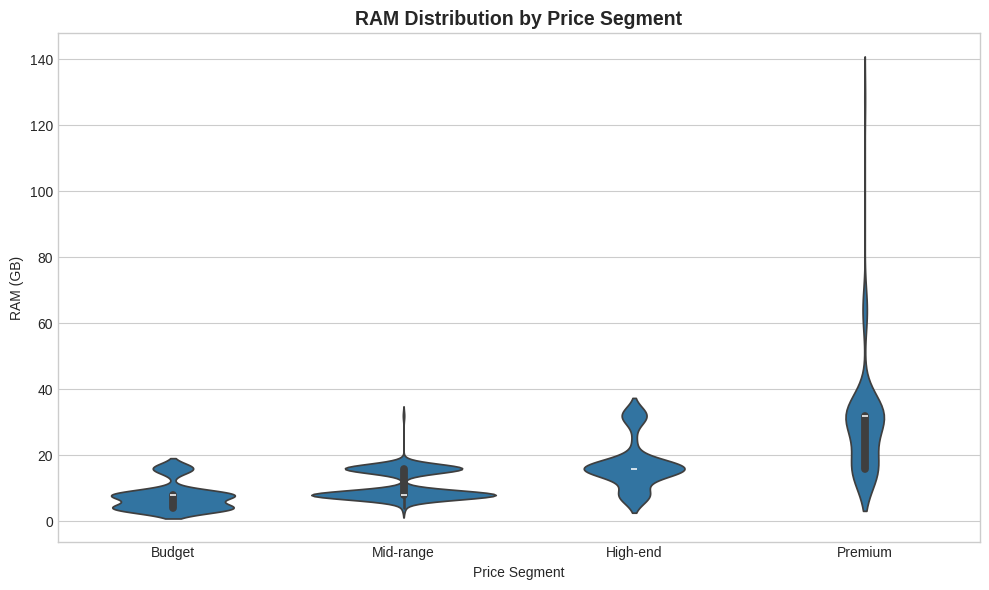

In [17]:
# Exercise 5: One-way ANOVA for RAM across Price Segments
print("="*60)
print("EXERCISE 5: One-way ANOVA (RAM across Price Segments)")
print("="*60)

# Prepare data for each group
segments = ['Budget', 'Mid-range', 'High-end', 'Premium']
groups = []

for seg in segments:
    data = df[df['Price_Segment'] == seg]['RAM_GB']
    groups.append(data)
    print(f"{seg:12s}: n={len(data):3d}, Mean RAM={data.mean():.2f} GB, Std={data.std():.2f}")

# Perform ANOVA
f_stat, p_anova = stats.f_oneway(*groups)

print(f"\nF-statistic: {f_stat:.4f}")
print(f"p-value: {p_anova:.4e}")
print(f"Decision: {'Reject H₀' if p_anova < 0.05 else 'Fail to reject H₀'} at α=0.05")

if p_anova < 0.05:
    print("=> Ít nhất một segment có mean RAM khác biệt có ý nghĩa.")
    print("   (Cần thực hiện post-hoc test như Tukey HSD để xác định nhóm nào khác nhau)")
else:
    print("=> Không có sự khác biệt có ý nghĩa về mean RAM giữa các segments.")
    
# Visualization: Violin plot for RAM by Price Segment
print("\n[Visualization] RAM Distribution by Price Segment:")
plt.figure(figsize=(10, 6))
sns.violinplot(x='Price_Segment', y='RAM_GB', data=df, order=segments)
plt.title('RAM Distribution by Price Segment', fontsize=14, fontweight='bold')
plt.xlabel('Price Segment')
plt.ylabel('RAM (GB)')
plt.tight_layout()
plt.show()

---
## Summary & Conclusion

### Key Findings:

1. **One-Sample Tests:**
   - Tỷ lệ laptop có GPU rời khác biệt đáng kể so với 50%
   - Mean RAM khác biệt có ý nghĩa so với 8GB

2. **Two-Sample Tests:**
   - Giá trung bình giữa laptop có GPU rời và GPU tích hợp khác nhau đáng kể
   - Tỷ lệ RAM ≥16GB khác nhau giữa các price segments

3. **Chi-Square Test:**
   - GPU Type và Price Segment có mối liên hệ (dependent)
   - RAM và Price Segment cũng có mối liên hệ

4. **ANOVA:**
   - Mean RAM khác nhau đáng kể giữa các price segments
   - Premium segment có RAM cao nhất, Budget có RAM thấp nhất

### Statistical Concepts Covered:
- ✅ Hypothesis testing framework (H₀, H₁, p-value, α)
- ✅ One-sample t-test & z-test
- ✅ Two-sample independent t-test & proportion test
- ✅ Paired t-test
- ✅ Chi-square test for independence
- ✅ One-way ANOVA
- ✅ Interpretation of p-values và statistical significance

### Practical Applications:
- Kiểm định giả thuyết giúp ra quyết định dựa trên dữ liệu
- Xác định mối quan hệ giữa các biến
- So sánh hiệu quả của các chiến lược marketing, sản phẩm, v.v.

---

**End of Lab 07**